## Expert Knowledge Worker

### A question answering agent that is an expert knowledge worker
### To be used by employees of Insurellm, an Insurance Tech company
### The agent needs to be accurate and the solution should be low cost.

This project will use RAG (Retrieval Augmented Generation) to ensure our question/answering assistant has high accuracy.

This first implementation will use a simple, brute-force type of RAG..

### Sidenote: Business applications of this week's projects

RAG is perhaps the most immediately applicable technique of anything that we cover in the course! In fact, there are commercial products that do precisely what we build this week: nuanced querying across large databases of information, such as company contracts or product specs. RAG gives you a quick-to-market, low cost mechanism for adapting an LLM to your business area.

## The knowledge base of the company is present in the knowledge-base directory or shared folder in this same folder.
There are 4 subfolders 
1. company - Containes files with some information on the company.
2. contracts - Contains files with some details on the contracts with other companies
3. employees - contains files with details of each employee
4. products - contains files with information on the products of the company.

Together this is our complete information on the company.

**Note - we will use gtp-4o-mini for this project**

In [ ]:
# imports

import os
import glob
from dotenv import load_dotenv
import gradio as gr
from openai import OpenAI

In [ ]:
# price is a factor for our company, so we're going to use a low cost model

MODEL = "gpt-4o-mini"

In [ ]:
# Load environment variables in a file called .env

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
openai = OpenAI()

### Below is the logic to load the data from the documents into a dictionary named context.

In [ ]:
# With massive thanks to student Dr John S. for fixing a bug in the below for Windows users!

context = {}

employees = glob.glob("knowledge-base/employees/*")

for employee in employees:
    name = employee.split(' ')[-1][:-3]
    doc = ""
    with open(employee, "r", encoding="utf-8") as f:
        doc = f.read()
    context[name]=doc

1. gob.glob function will put names of all the files of the directory employees in the list employees.

    ['knowledge-base/employees/Alex Chen.md', 'knowledge-base/employees/Oliver Spencer.md', 'knowledge-base/employees/Emily Tran.md', 
    'knowledge-base/employees/Jordan Blake.md', 'knowledge-base/employees/Avery Lancaster.md', 'knowledge-base/employees/Maxine Thompson.md', 
    'knowledge-base/employees/Samantha Greene.md', 'knowledge-base/employees/Alex Thomson.md', 'knowledge-base/employees/Samuel Trenton.md', 
    'knowledge-base/employees/Alex Harper.md', 'knowledge-base/employees/Jordan K. Bishop.md', 'knowledge-base/employees/Emily Carter.md']
    
2. The next code splits the name of the employee.
3. Then each of the document with the name as employee name is open and the data in it is read.
4. Then in the last step , the dictionary is created with the key as the employee name and the value is the complete blob of information.
    ex - {'Chen': '# HR Record\n\n# Alex Chen\n\n## Summary\n- **Date of Birth:** March 15, 1990  \n- **Job Title:** Backend Software Engineer .....

In [ ]:
context["Lancaster"]

### Similarly we read the products data in the file and put it in the context dictionary

In [ ]:
products = glob.glob("knowledge-base/products/*")

for product in products:
    name = product.split(os.sep)[-1][:-3]
    doc = ""
    with open(product, "r", encoding="utf-8") as f:
        doc = f.read()
    context[name]=doc

In [ ]:
# The product names will also get added to the employee names
context.keys()

### Our System Message
**Telling models authoratatively to not invent things and simply say that it does not know the answer is actually effective in reducing hallucination**

In [ ]:
system_message = """You are an expert in answering accurate questions about Insurellm, the Insurance Tech company. 
Give brief, accurate answers. If you don't know the answer, say so. Do not make anything up if you haven't been provided with relevant context."""

### Here we are defining a function that will search if the message we passed in the function has the keywords present in the context dictionary.
**It is checking if the key.lower() is present in the message(). So for an input "Who is lancaster ?" , it will be checked if all the keys including "lancaster" is present in this message , if so then it will be added to the list relevant_context.**

If the questions is - `"Who is Avery and what is carllm?"` then both Avery and carlim's data will be added to the relevant_context dictionary.

**Note- This code is just a non-intelligent code. If we type the wrong name of employee or skip some information like Alex lanchaster instead of Avery Lanchester on the employee then we will not get the actual results we want. We will see better way to do this in the future.**

In [ ]:
def get_relevant_context(message):
    relevant_context = []
    for context_title, context_details in context.items():
        if context_title.lower() in message.lower():
            relevant_context.append(context_details)
    return relevant_context          

In [ ]:
get_relevant_context("Who is lancaster?")

In [ ]:
get_relevant_context("Who is Avery and what is carllm?")

### We are adding context to our message that will then be passed as a prompt in this function.

In [ ]:
def add_context(message):
    relevant_context = get_relevant_context(message)
    if relevant_context:
        message += "\n\nThe following additional context might be relevant in answering this question:\n\n"
        for relevant in relevant_context:
            message += relevant + "\n\n"
    return message

In [ ]:
print(add_context("Who is Alex Lancaster?"))

### Below is our chat function that gradio expects. Here we are simply calling the add_context method to get some data in the context then passing everything in the user prompt

In [ ]:
def chat(message, history):
    messages = [{"role": "system", "content": system_message}] + history
    message = add_context(message)
    messages.append({"role": "user", "content": message})

    stream = openai.chat.completions.create(model=MODEL, messages=messages, stream=True)

    response = ""
    for chunk in stream:
        response += chunk.choices[0].delta.content or ''
        yield response

## Now we will bring this up in Gradio using the Chat interface -

A quick and easy way to prototype a chat with an LLM

In [ ]:
view = gr.ChatInterface(chat, type="messages").launch()

### Output-
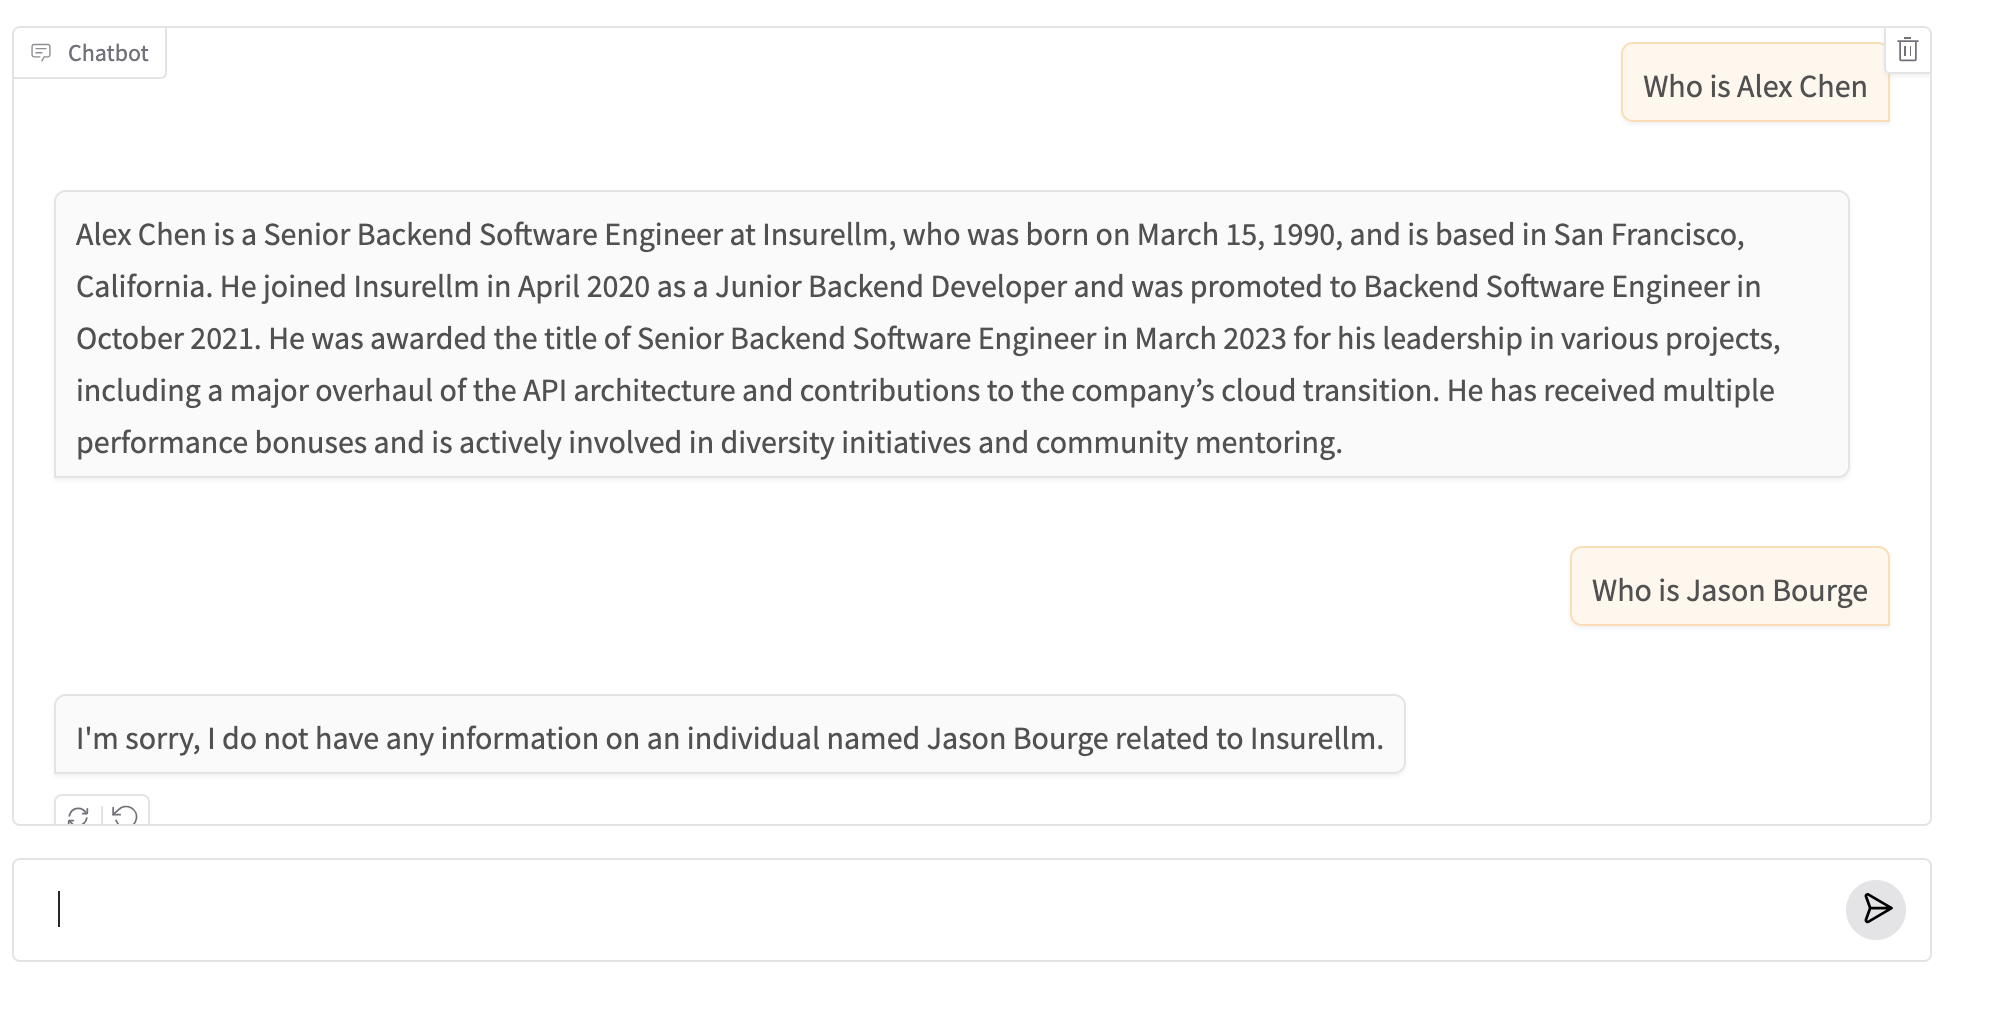